In [2]:
from pathlib import Path
from collections import Counter
import os
import json
import pandas as pd

In [3]:
DATA_DIR = Path("../dataset/assembly-joint")
print("Exists:", DATA_DIR.exists())
print("Resolved:", DATA_DIR.resolve())

Exists: True
Resolved: /Users/jana/Documents/Github/cad-assembly-pattern-mining/dataset/assembly-joint


In [4]:
top_items = list(DATA_DIR.iterdir())
[(p.name, "DIR" if p.is_dir() else "FILE") for p in top_items]

[('.DS_Store', 'FILE'),
 ('train_test.json', 'FILE'),
 ('joint', 'DIR'),
 ('Fusion 360 Gallery Dataset Public License.docx', 'FILE')]

In [5]:
JOINT_DIR = DATA_DIR / "joint"
joint_items = list(JOINT_DIR.iterdir())

print("Number of items inside joint/:", len(joint_items))
[(p.name, "DIR" if p.is_dir() else "FILE") for p in joint_items[:20]]

Number of items inside joint/: 130429


[('joint_set_00839.json', 'FILE'),
 ('51744_cd355565_0005_2.json', 'FILE'),
 ('45359_1768ab3f_0008_2.smt', 'FILE'),
 ('joint_set_17133.png', 'FILE'),
 ('joint_set_18200.png', 'FILE'),
 ('49695_155b7a8e_0000_1.step', 'FILE'),
 ('129078_9934147b_0006_1.step', 'FILE'),
 ('joint_set_02804.json', 'FILE'),
 ('34333_7acb47f5_0015_2.step', 'FILE'),
 ('42203_33083e24_0025_1.smt', 'FILE'),
 ('joint_set_07320.png', 'FILE'),
 ('53216_2857e8ac_0026_2.smt', 'FILE'),
 ('26481_9536a45e_0005_1.smt', 'FILE'),
 ('49132_b56fa79b_0006_2.json', 'FILE'),
 ('joint_set_03716.json', 'FILE'),
 ('joint_set_01989.png', 'FILE'),
 ('75966_08c4ab3e_0007_1.step', 'FILE'),
 ('24217_f4469ff7_0000_1.step', 'FILE'),
 ('joint_set_08013.png', 'FILE'),
 ('45303_48d14b32_0009_2.obj', 'FILE')]

In [6]:
all_joint_files = []
for root, dirs, files in os.walk(JOINT_DIR):
    for f in files:
        all_joint_files.append(Path(root) / f)

print("Total files inside joint/:", len(all_joint_files))
all_joint_files[:20]

Total files inside joint/: 130429


[PosixPath('../dataset/assembly-joint/joint/joint_set_00839.json'),
 PosixPath('../dataset/assembly-joint/joint/51744_cd355565_0005_2.json'),
 PosixPath('../dataset/assembly-joint/joint/45359_1768ab3f_0008_2.smt'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_17133.png'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_18200.png'),
 PosixPath('../dataset/assembly-joint/joint/49695_155b7a8e_0000_1.step'),
 PosixPath('../dataset/assembly-joint/joint/129078_9934147b_0006_1.step'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_02804.json'),
 PosixPath('../dataset/assembly-joint/joint/34333_7acb47f5_0015_2.step'),
 PosixPath('../dataset/assembly-joint/joint/42203_33083e24_0025_1.smt'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_07320.png'),
 PosixPath('../dataset/assembly-joint/joint/53216_2857e8ac_0026_2.smt'),
 PosixPath('../dataset/assembly-joint/joint/26481_9536a45e_0005_1.smt'),
 PosixPath('../dataset/assembly-joint/joint/49132_b56fa79b_0006_2.json'),


In [7]:
suffix_counts = Counter([f.suffix.lower() for f in all_joint_files])
suffix_counts

Counter({'.json': 42186,
         '.smt': 23029,
         '.step': 23029,
         '.obj': 23029,
         '.png': 19156})

In [8]:
split_path = DATA_DIR / "train_test.json"

with open(split_path, "r", encoding="utf-8") as f:
    split_data = json.load(f)

type(split_data)

dict

In [9]:
if isinstance(split_data, dict):
    print("Top-level keys:", list(split_data.keys()))
    
    for k, v in split_data.items():
        print(f"\nKEY: {k}")
        print("TYPE:", type(v))
        if isinstance(v, list):
            print("LENGTH:", len(v))
            print("FIRST 5:", v[:5])
        elif isinstance(v, dict):
            print("SUBKEYS:", list(v.keys())[:10])
else:
    print("Unexpected structure")
    print(split_data[:5] if isinstance(split_data, list) else split_data)

Top-level keys: ['train', 'validation', 'test', 'uniform_test']

KEY: train
TYPE: <class 'list'>
LENGTH: 13405
FIRST 5: ['joint_set_09422', 'joint_set_17043', 'joint_set_18969', 'joint_set_01074', 'joint_set_15117']

KEY: validation
TYPE: <class 'list'>
LENGTH: 1916
FIRST 5: ['joint_set_10639', 'joint_set_03832', 'joint_set_04309', 'joint_set_01046', 'joint_set_06460']

KEY: test
TYPE: <class 'list'>
LENGTH: 1926
FIRST 5: ['joint_set_13082', 'joint_set_08045', 'joint_set_01324', 'joint_set_10371', 'joint_set_10420']

KEY: uniform_test
TYPE: <class 'list'>
LENGTH: 1909
FIRST 5: ['joint_set_15871', 'joint_set_15717', 'joint_set_06625', 'joint_set_14939', 'joint_set_17920']


In [10]:
json_files = [f for f in all_joint_files if f.suffix.lower() == ".json"]
print("JSON files found:", len(json_files))
json_files[:10]

JSON files found: 42186


[PosixPath('../dataset/assembly-joint/joint/joint_set_00839.json'),
 PosixPath('../dataset/assembly-joint/joint/51744_cd355565_0005_2.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_02804.json'),
 PosixPath('../dataset/assembly-joint/joint/49132_b56fa79b_0006_2.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_03716.json'),
 PosixPath('../dataset/assembly-joint/joint/41113_e7d93a39_0000_1.json'),
 PosixPath('../dataset/assembly-joint/joint/24302_2bcddd22_0006_1.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_15338.json'),
 PosixPath('../dataset/assembly-joint/joint/47210_36226953_0006_1.json'),
 PosixPath('../dataset/assembly-joint/joint/51601_2616f89b_0004_2.json')]

In [11]:
sample_path = json_files[0]
print("Sample file:", sample_path)

with open(sample_path, "r", encoding="utf-8") as f:
    sample_data = json.load(f)

print(type(sample_data))

Sample file: ../dataset/assembly-joint/joint/joint_set_00839.json
<class 'dict'>


In [12]:
if isinstance(sample_data, dict):
    print("Top-level keys:", list(sample_data.keys()))
    
    for k, v in sample_data.items():
        print(f"\n{k}: {type(v)}")
        if isinstance(v, dict):
            print("  subkeys:", list(v.keys())[:10])
        elif isinstance(v, list):
            print("  length:", len(v))
            print("  first item:", v[0] if len(v) > 0 else None)
        else:
            print(" ", v)
elif isinstance(sample_data, list):
    print("List length:", len(sample_data))
    print("First item:", sample_data[0] if len(sample_data) > 0 else None)

Top-level keys: ['body_one', 'body_two', 'joints', 'contacts', 'holes']

body_one: <class 'str'>
  122423_9ab69fbb_0003_2

body_two: <class 'str'>
  122423_9ab69fbb_0002_2

joints: <class 'list'>
  length: 1
  first item: {'name': 'Rev6', 'type': 'Joint', 'joint_motion': {'joint_type': 'RevoluteJointType', 'rotation_axis': 'ZAxisJointDirection', 'rotation_limits': {'maximum_value': 0.0, 'minimum_value': 0.0, 'rest_value': 0.0, 'is_maximum_value_enabled': False, 'is_minimum_value_enabled': False, 'is_rest_value_enabled': False}}, 'geometry_or_origin_one': {'type': 'JointGeometry', 'geometry_type': 'JointBRepEdgeGeometry', 'key_point_type': 'CenterKeyPoint', 'origin': {'type': 'Point3D', 'x': 0.0, 'y': 2.0, 'z': 0.0}, 'primary_axis_vector': {'type': 'Vector3D', 'x': 0.0, 'y': 0.0, 'z': 1.0, 'length': 1.0}, 'secondary_axis_vector': {'type': 'Vector3D', 'x': 1.0, 'y': 0.0, 'z': 0.0, 'length': 1.0}, 'tertiary_axis_vector': {'type': 'Vector3D', 'x': 0.0, 'y': 1.0, 'z': 0.0, 'length': 1.0}, '

## Building Split lookup

In [13]:
split_lookup = {}

for split_name, ids in split_data.items():
    for sid in ids:
        split_lookup[sid] = split_name

print("Total split ids:", len(split_lookup))
list(split_lookup.items())[:10]

Total split ids: 19156


[('joint_set_09422', 'train'),
 ('joint_set_17043', 'train'),
 ('joint_set_18969', 'train'),
 ('joint_set_01074', 'train'),
 ('joint_set_15117', 'train'),
 ('joint_set_05293', 'train'),
 ('joint_set_02096', 'train'),
 ('joint_set_05022', 'train'),
 ('joint_set_11764', 'train'),
 ('joint_set_15843', 'train')]

In [14]:
joint_set_files = [
    f for f in json_files
    if f.stem.startswith("joint_set_")
]

print("Number of joint_set JSON files:", len(joint_set_files))
joint_set_files[:10]

Number of joint_set JSON files: 19156


[PosixPath('../dataset/assembly-joint/joint/joint_set_00839.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_02804.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_03716.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_15338.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_17305.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_12107.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_06514.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_04529.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_03346.json'),
 PosixPath('../dataset/assembly-joint/joint/joint_set_04483.json')]

In [15]:
def extract_joint_types(joints):
    joint_types = []
    for j in joints:
        joint_motion = j.get("joint_motion", {})
        jt = joint_motion.get("joint_type")
        if jt is not None:
            joint_types.append(jt)
    return joint_types

In [16]:
def parse_joint_set_file(path, split_lookup):
    with open(path, "r", encoding="utf-8") as f:
        rec = json.load(f)
    
    sample_id = path.stem  # e.g., joint_set_00839
    joints = rec.get("joints", [])
    contacts = rec.get("contacts", [])
    holes = rec.get("holes", [])
    
    joint_types = extract_joint_types(joints)
    unique_joint_types = sorted(set(joint_types))
    
    row = {
        "sample_id": sample_id,
        "split": split_lookup.get(sample_id, "unknown"),
        "body_one": rec.get("body_one"),
        "body_two": rec.get("body_two"),
        "n_joints": len(joints),
        "n_contacts": len(contacts),
        "n_holes": len(holes),
        "has_contact": int(len(contacts) > 0),
        "has_hole": int(len(holes) > 0),
        "joint_types": joint_types,
        "joint_types_str": ", ".join(joint_types),
        "n_unique_joint_types": len(unique_joint_types),
    }
    
    row["primary_joint_type"] = joint_types[0] if len(joint_types) > 0 else None
    
    return row

## Parsing the whole dataset

In [17]:
rows = []

for i, path in enumerate(joint_set_files):
    try:
        row = parse_joint_set_file(path, split_lookup)
        rows.append(row)
    except Exception as e:
        print(f"Error reading {path.name}: {e}")
    
    if (i + 1) % 2000 == 0:
        print(f"Parsed {i+1:,} / {len(joint_set_files):,}")

Parsed 2,000 / 19,156
Parsed 4,000 / 19,156
Parsed 6,000 / 19,156
Parsed 8,000 / 19,156
Parsed 10,000 / 19,156
Parsed 12,000 / 19,156
Parsed 14,000 / 19,156
Parsed 16,000 / 19,156
Parsed 18,000 / 19,156


## Create Dataframe

In [18]:
df_pairs = pd.DataFrame(rows)
print(df_pairs.shape)
df_pairs.head()

(19156, 13)


,sample_id,split,body_one,body_two,n_joints,n_contacts,n_holes,has_contact,has_hole,joint_types,joint_types_str,n_unique_joint_types,primary_joint_type
0,joint_set_00839,train,122423_9ab69fbb_0003_2,122423_9ab69fbb_0002_2,1,2,3,1,1,[RevoluteJointType],RevoluteJointType,1,RevoluteJointType
1,joint_set_02804,test,30273_ff246341_0008_1,30273_ff246341_0012_2,1,3,0,1,0,[CylindricalJointType],CylindricalJointType,1,CylindricalJointType
2,joint_set_03716,train,22430_c6f08b03_0018_1,22430_c6f08b03_0018_2,8,24,0,1,0,"[RigidJointType, RigidJointType, RigidJointTyp...","RigidJointType, RigidJointType, RigidJointType...",1,RigidJointType
3,joint_set_15338,uniform_test,38198_7c60c095_0002_1,38198_7c60c095_0003_2,2,6,3,1,1,"[RevoluteJointType, RevoluteJointType]","RevoluteJointType, RevoluteJointType",1,RevoluteJointType
4,joint_set_17305,validation,65017_77c9bf53_0029_1,61373_b4862939_0005_2,4,4,5,1,1,"[RigidJointType, RigidJointType, RigidJointTyp...","RigidJointType, RigidJointType, RigidJointType...",1,RigidJointType


In [19]:
print(df_pairs["split"].value_counts(dropna=False))
print(df_pairs["n_joints"].describe())
print(df_pairs["n_contacts"].describe())
print(df_pairs["n_holes"].describe())

split
train           13405
test             1926
validation       1916
uniform_test     1909
Name: count, dtype: int64
count    19156.000000
mean         1.678221
std          1.851926
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         74.000000
Name: n_joints, dtype: float64
count    19156.000000
mean         3.100543
std          6.900767
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        342.000000
Name: n_contacts, dtype: float64
count    19156.000000
mean         4.304918
std         10.772627
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        452.000000
Name: n_holes, dtype: float64


## Joint Type distribution

In [20]:
joint_type_counts = df_pairs["primary_joint_type"].value_counts(dropna=False)
joint_type_counts

primary_joint_type
RigidJointType          10306
RevoluteJointType        5450
CylindricalJointType     1743
SliderJointType          1139
PlanarJointType           303
BallJointType             163
PinSlotJointType           52
Name: count, dtype: int64

## Joint Types plot

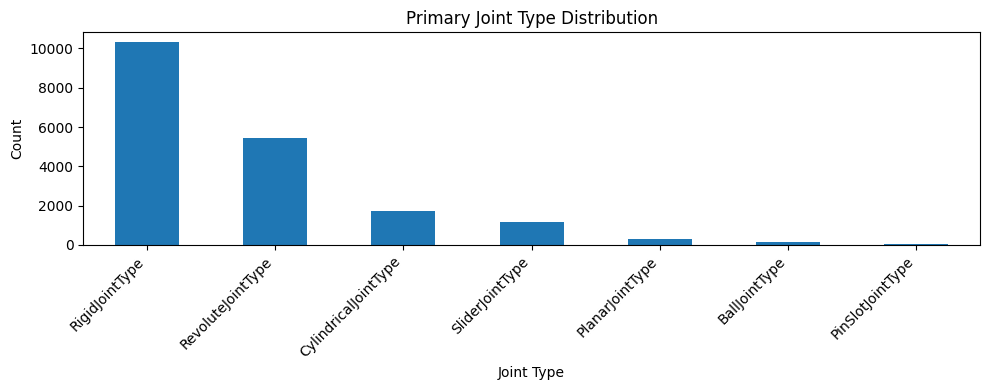

In [21]:
import matplotlib.pyplot as plt

joint_type_counts.head(15).plot(kind="bar", figsize=(10, 4))
plt.title("Primary Joint Type Distribution")
plt.xlabel("Joint Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Contacts and holes Plot

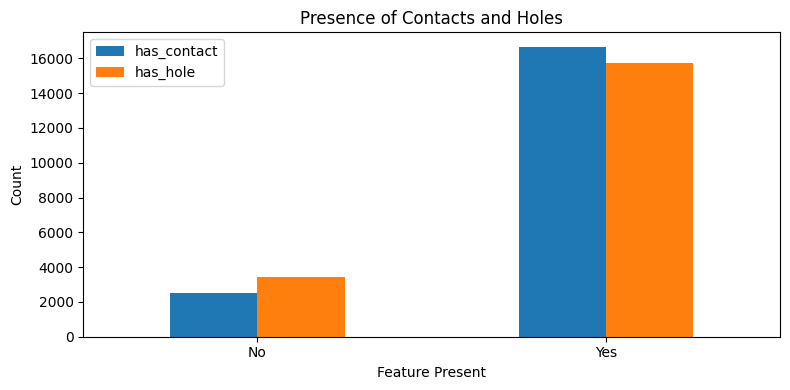

In [22]:
fig_df = pd.DataFrame({
    "has_contact": df_pairs["has_contact"].value_counts().sort_index(),
    "has_hole": df_pairs["has_hole"].value_counts().sort_index(),
}).fillna(0)

fig_df.index = ["No", "Yes"]
fig_df.plot(kind="bar", figsize=(8, 4))
plt.title("Presence of Contacts and Holes")
plt.xlabel("Feature Present")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Save Processed Dataset

In [23]:
output_path = Path("../dataset/processed/joint_pair_features.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_pairs.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: ../dataset/processed/joint_pair_features.csv


## Analysis of the above plots

The Assembly-Joint dataset shows a highly skewed distribution of primary joint types. Rigid joints are the most common interaction type, followed by revolute joints, while cylindrical, slider, planar, ball, and pin-slot joints appear much less frequently. This indicates that human-designed CAD interactions are dominated by a small number of common relationship types. In addition, most interaction samples contain both contacts and holes, suggesting that many CAD part interactions are geometrically rich rather than defined by joint labels alone.